**Предобработка**

title - название лота на eBay.
Это заголовок объявления, по которому можно понять, какой именно комикс, набор комиксов или издание продаётся.

price - цена лота в текстовом виде.

extracted_price - цена лота в числовом виде.

reviews - количество отзывов по товару, если оно отображается в выдаче.
Этот признак встречается редко, поэтому он оказался слабо заполненным и не использовался в анализе.

condition — состояние товара.

buying_format — формат покупки.
Показывает, как можно приобрести товар: например, Buy It Now или or Best Offer.

seller_name — имя продавца.

seller_reviews — количество отзывов у продавца.
Характеризует опыт и активность продавца на площадке.

seller_feedback — процент положительного фидбэка продавца.
Показывает репутацию продавца и уровень доверия со стороны покупателей.

sold_text — текстовое поле, в котором иногда содержится информация о продажах.
Например, там может быть строка вида 187 sold, но иногда туда попадают и другие тексты вроде скидок или акций.

return_info — информация о возврате товара.

location — информация о местоположении товара или продавца.

link — ссылка на конкретный лот на eBay.

source_query — поисковый запрос, по которому лот был найден.
Например: comics, graphic novels, webcomics.

source_page — номер страницы поисковой выдачи, с которой был собран лот.


In [166]:
ebay_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8160 entries, 0 to 8159
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   item_id          8160 non-null   int64  
 1   title            7982 non-null   object 
 2   price            8160 non-null   object 
 3   extracted_price  7669 non-null   float64
 4   reviews          486 non-null    float64
 5   condition        6774 non-null   object 
 6   buying_format    8160 non-null   object 
 7   seller_name      8160 non-null   object 
 8   seller_reviews   8160 non-null   int64  
 9   seller_feedback  8160 non-null   float64
 10  sold_text        1873 non-null   object 
 11  return_info      4530 non-null   object 
 12  location         7601 non-null   object 
 13  link             8160 non-null   object 
 14  source_query     8160 non-null   object 
 15  source_page      8160 non-null   int64  
dtypes: float64(3), int64(3), object(10)
memory usage: 1020.1+ KB

In [121]:
import pandas as pd
import numpy as np

ebay_df = pd.read_excel('ebay_comics.xlsx')
ebay_df

,item_id,title,price,extracted_price,reviews,condition,buying_format,seller_name,seller_reviews,seller_feedback,sold_text,return_info,location,link,source_query,source_page
0,295102178301,"LARGE 25 COMICS BOOK LOT-MARVEL, DC, INDIES- F...",$22.49,22.49,NaN,New (Other),or Best Offer,hadleycomics,1600,99.8,Save up to 10% when you buy more,"1,248 sold",Free returns,https://www.ebay.com/itm/295102178301,comics,1
1,376968283312,MARVEL/DC: SPIDER-MAN/SUPERMAN #1 *Dang! So Ma...,$7.89 to $89.99,NaN,NaN,Brand New,Buy It Now,odineyes_oddities,7800,100.0,20% off 20+ with coupon,Free returns,Located in United States,https://www.ebay.com/itm/376968283312,comics,1
2,188257989469,Dead Samurai #6 Cover C Drax Gal Cover,$5.99,5.99,NaN,New (Other),or Best Offer,torpedocomics,7700,100.0,NaN,NaN,Located in United States,https://www.ebay.com/itm/188257989469,comics,1
3,287039504394,DC Marvel Superman Spider-Man #1 (One Shot) Co...,$14.99,14.99,NaN,Brand New,Buy It Now,si-fi_toys,14400,99.6,NaN,187 sold,Free returns,https://www.ebay.com/itm/287039504394,comics,1
4,284701338991,lot of 100 comics 80s 90s 2000 Marvel Dc Horse...,$28.95,28.95,NaN,Pre-Owned,Buy It Now,77kings,8200,99.9,NaN,"1,064 sold",Located in United States,https://www.ebay.com/itm/284701338991,comics,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8155,137208789148,Mirror Mirror 2,$27.77,27.77,NaN,Pre-Owned,Buy It Now,readingebooks,20100,99.7,NaN,NaN,Located in United States,https://www.ebay.com/itm/137208789148,comic anthology,8
8156,406022997316,"Street Fighter 2 Comic Anthology, VG, no tears...",$99.73,99.73,NaN,New (Other),or Best Offer,kiyma87,314,99.4,NaN,NaN,Located in Japan,https://www.ebay.com/itm/406022997316,comic anthology,8
8157,389350082654,Twilight Zone Comic #37 Gold Key May 1971 Vint...,$8.40,8.40,NaN,Pre-Owned,or Best Offer,nat_444992,24,100.0,NaN,NaN,Located in United States,https://www.ebay.com/itm/389350082654,comic anthology,8
8158,137086011864,"The Nib Lot Issues 1-8, Death Family Empire Sc...",$94.33,94.33,NaN,Pre-Owned,or Best Offer,oregonsellerspdx,2800,99.1,NaN,Free returns,Located in United States,https://www.ebay.com/itm/137086011864,comic anthology,8


In [123]:
ebay_df.head(2)

,item_id,title,price,extracted_price,reviews,condition,buying_format,seller_name,seller_reviews,seller_feedback,sold_text,return_info,location,link,source_query,source_page
0,295102178301,"LARGE 25 COMICS BOOK LOT-MARVEL, DC, INDIES- F...",$22.49,22.49,NaN,New (Other),or Best Offer,hadleycomics,1600,99.8,Save up to 10% when you buy more,"1,248 sold",Free returns,https://www.ebay.com/itm/295102178301,comics,1
1,376968283312,MARVEL/DC: SPIDER-MAN/SUPERMAN #1 *Dang! So Ma...,$7.89 to $89.99,NaN,NaN,Brand New,Buy It Now,odineyes_oddities,7800,100.0,20% off 20+ with coupon,Free returns,Located in United States,https://www.ebay.com/itm/376968283312,comics,1


In [124]:
ebay_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8160 entries, 0 to 8159
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   item_id          8160 non-null   int64  
 1   title            7982 non-null   object 
 2   price            8160 non-null   object 
 3   extracted_price  7669 non-null   float64
 4   reviews          486 non-null    float64
 5   condition        6774 non-null   object 
 6   buying_format    8160 non-null   object 
 7   seller_name      8160 non-null   object 
 8   seller_reviews   8160 non-null   int64  
 9   seller_feedback  8160 non-null   float64
 10  sold_text        1873 non-null   object 
 11  return_info      4530 non-null   object 
 12  location         7601 non-null   object 
 13  link             8160 non-null   object 
 14  source_query     8160 non-null   object 
 15  source_page      8160 non-null   int64  
dtypes: float64(3), int64(3), object(10)
memory usage: 1020.1+ KB

In [125]:
ebay_df.duplicated().sum()

np.int64(0)

In [126]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table = mis_val_table.rename(columns={0: 'Missing Values', 1: '% of Total Values'})
    mis_val_table = mis_val_table[mis_val_table.iloc[:,1] != 0].sort_values('% of Total Values', ascending=False).round(1)
    return mis_val_table

missing_values_table(ebay_df)

,Missing Values,% of Total Values
reviews,7674,94.0
sold_text,6287,77.0
return_info,3630,44.5
condition,1386,17.0
location,559,6.9
extracted_price,491,6.0
title,178,2.2


In [127]:
ebay_df['item_id'].nunique()

5984

In [128]:
ebay_df['item_id'].duplicated().sum()

np.int64(2176)

In [129]:
ebay_df[ebay_df['item_id'].duplicated(keep=False)].sort_values('item_id').head(10)

,item_id,title,price,extracted_price,reviews,condition,buying_format,seller_name,seller_reviews,seller_feedback,sold_text,return_info,location,link,source_query,source_page
6145,115743831216,WEB OF SPIDERMAN 26 (9.8) MARVEL (B017),$50.00,50.00,NaN,NaN,or Best Offer,allfunstuff2003,10300,98.8,NaN,Free returns,Located in United States,https://www.ebay.com/itm/115743831216,webcomics,8
5854,115743831216,WEB OF SPIDERMAN 26 (9.8) MARVEL (B017),$50.00,50.00,NaN,NaN,or Best Offer,allfunstuff2003,10300,98.8,NaN,Free returns,Located in United States,https://www.ebay.com/itm/115743831216,webcomics,7
7329,116486647531,BIG MOUTH #7- Pat Moriarty*Dame Darcy*David Gr...,$12.99,12.99,NaN,New (Other),or Best Offer,scottm6136,21300,99.9,NaN,NaN,Located in United States,https://www.ebay.com/itm/116486647531,comic anthology,5
7986,116486647531,BIG MOUTH #7- Pat Moriarty*Dame Darcy*David Gr...,$12.99,12.99,NaN,New (Other),or Best Offer,scottm6136,21300,99.9,NaN,NaN,Located in United States,https://www.ebay.com/itm/116486647531,comic anthology,8
7128,116532309114,Now #4: The New Comics Anthology First Edition...,$17.99,17.99,NaN,Pre-Owned,or Best Offer,noopotamusrex,1800,100.0,NaN,NaN,Located in United States,https://www.ebay.com/itm/116532309114,comic anthology,4
7224,116532309114,Now #4: The New Comics Anthology First Edition...,$17.99,17.99,NaN,Pre-Owned,or Best Offer,noopotamusrex,1800,100.0,NaN,NaN,Located in United States,https://www.ebay.com/itm/116532309114,comic anthology,5
1525,116538513584,DC Comics Batman (1978-1994) Vol 1 Choose Your...,$0.99 to $35.99,NaN,NaN,New (Other),Buy It Now,doob67,1600,100.0,NaN,NaN,Located in United States,https://www.ebay.com/itm/116538513584,comics,7
2055,116538513584,DC Comics Batman (1978-1994) Vol 1 Choose Your...,$0.99 to $35.99,NaN,NaN,New (Other),Buy It Now,doob67,1600,100.0,NaN,NaN,Located in United States,https://www.ebay.com/itm/116538513584,comic books,2
872,116563506755,"DC Comics Batman (Vol. 1) SIngle issues, You P...",$1.00 to $35.00,NaN,NaN,Pre-Owned,Buy It Now,keltoi14,16400,99.9,NaN,NaN,Located in United States,https://www.ebay.com/itm/116563506755,comics,4
666,116563506755,"DC Comics Batman (Vol. 1) SIngle issues, You P...",$1.00 to $35.00,NaN,NaN,Pre-Owned,Buy It Now,keltoi14,16400,99.9,NaN,NaN,Located in United States,https://www.ebay.com/itm/116563506755,comics,3


In [130]:
ebay_df_clean = ebay_df.copy()

In [131]:
ebay_df_clean = ebay_df_clean.drop_duplicates(subset=['item_id'])
ebay_df_clean.shape

(5984, 16)

In [132]:
ebay_df_clean = ebay_df_clean[~ebay_df_clean['title'].isna()]
ebay_df_clean.shape

(5860, 16)

In [133]:
ebay_df_clean['sold_text_all'] = ebay_df_clean['sold_text'].fillna('') + ' ' + ebay_df_clean['return_info'].fillna('') + ' ' + ebay_df_clean['location'].fillna('')

In [134]:
ebay_df_clean['sold_cnt'] = ebay_df_clean['sold_text_all'].str.extract(r'([\d,]+)\s+sold', expand=False)
ebay_df_clean['sold_cnt'] = ebay_df_clean['sold_cnt'].str.replace(',', '', regex=False)
ebay_df_clean['sold_cnt'] = ebay_df_clean['sold_cnt'].astype('float')

Для более удобного анализа из текстовых полей, в которых иногда встречалась информация о продажах вида 187 sold или 1,248 sold, был сформирован новый признак sold_cnt. Для этого из объединённого текстового поля регулярным выражением извлекалось число перед словом sold, затем из него убирались запятые, после чего значение переводилось в числовой формат. Таким образом, sold_cnt показывает количество продаж лота в тех случаях, когда эта информация присутствовала в объявлении. Однако число продаж удалось извлечь не для всех наблюдений, поэтому дополнительно был создан бинарный признак sold_flag: если значение sold_cnt присутствует, то sold_flag = 1, если отсутствует - sold_flag = 0. В результате sold_cnt использовался как количественный показатель интенсивности продаж, а sold_flag - как критерий успешности, позволяющий разделить лоты на имеющие и не имеющие зафиксированный сигнал продаж.

In [135]:
ebay_df_clean['sold_flag'] = (~ebay_df_clean['sold_cnt'].isna()).astype('int')

In [136]:
ebay_df_clean[['sold_text', 'return_info', 'location', 'sold_cnt', 'sold_flag']]

,sold_text,return_info,location,sold_cnt,sold_flag
0,Save up to 10% when you buy more,"1,248 sold",Free returns,1248.0,1
1,20% off 20+ with coupon,Free returns,Located in United States,NaN,0
2,NaN,NaN,Located in United States,NaN,0
3,NaN,187 sold,Free returns,187.0,1
4,NaN,"1,064 sold",Located in United States,1064.0,1
...,...,...,...,...,...
8153,NaN,NaN,Located in United States,NaN,0
8154,5 watchers,Free returns,Located in Japan,NaN,0
8155,NaN,NaN,Located in United States,NaN,0
8156,NaN,NaN,Located in Japan,NaN,0


In [137]:
ebay_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5860 entries, 0 to 8157
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   item_id          5860 non-null   int64  
 1   title            5860 non-null   object 
 2   price            5860 non-null   object 
 3   extracted_price  5585 non-null   float64
 4   reviews          393 non-null    float64
 5   condition        4941 non-null   object 
 6   buying_format    5860 non-null   object 
 7   seller_name      5860 non-null   object 
 8   seller_reviews   5860 non-null   int64  
 9   seller_feedback  5860 non-null   float64
 10  sold_text        1274 non-null   object 
 11  return_info      3101 non-null   object 
 12  location         5504 non-null   object 
 13  link             5860 non-null   object 
 14  source_query     5860 non-null   object 
 15  source_page      5860 non-null   int64  
 16  sold_text_all    5860 non-null   object 
 17  sold_cnt         56

**Анализ и визуализация**

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

In [139]:
ebay_df_clean = ebay_df_clean.drop(columns=['sold_text_all'])

ebay_df_analysis = ebay_df_clean[['item_id', 'title', 'extracted_price', 'reviews', 'seller_reviews', 'seller_feedback', 'sold_cnt', 'sold_flag', 'condition', 'buying_format', 'source_query']].copy()
ebay_df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5860 entries, 0 to 8157
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   item_id          5860 non-null   int64  
 1   title            5860 non-null   object 
 2   extracted_price  5585 non-null   float64
 3   reviews          393 non-null    float64
 4   seller_reviews   5860 non-null   int64  
 5   seller_feedback  5860 non-null   float64
 6   sold_cnt         563 non-null    float64
 7   sold_flag        5860 non-null   int64  
 8   condition        4941 non-null   object 
 9   buying_format    5860 non-null   object 
 10  source_query     5860 non-null   object 
dtypes: float64(4), int64(3), object(4)
memory usage: 549.4+ KB


Перед анализом оставляем только те признаки, которые действительно будем использовать. Основным критерием успешности будет sold_flag, так как он есть для всей выборки. Показатель sold_cnt будем использовать дополнительно только для той части лотов, где удалось извлечь число продаж.

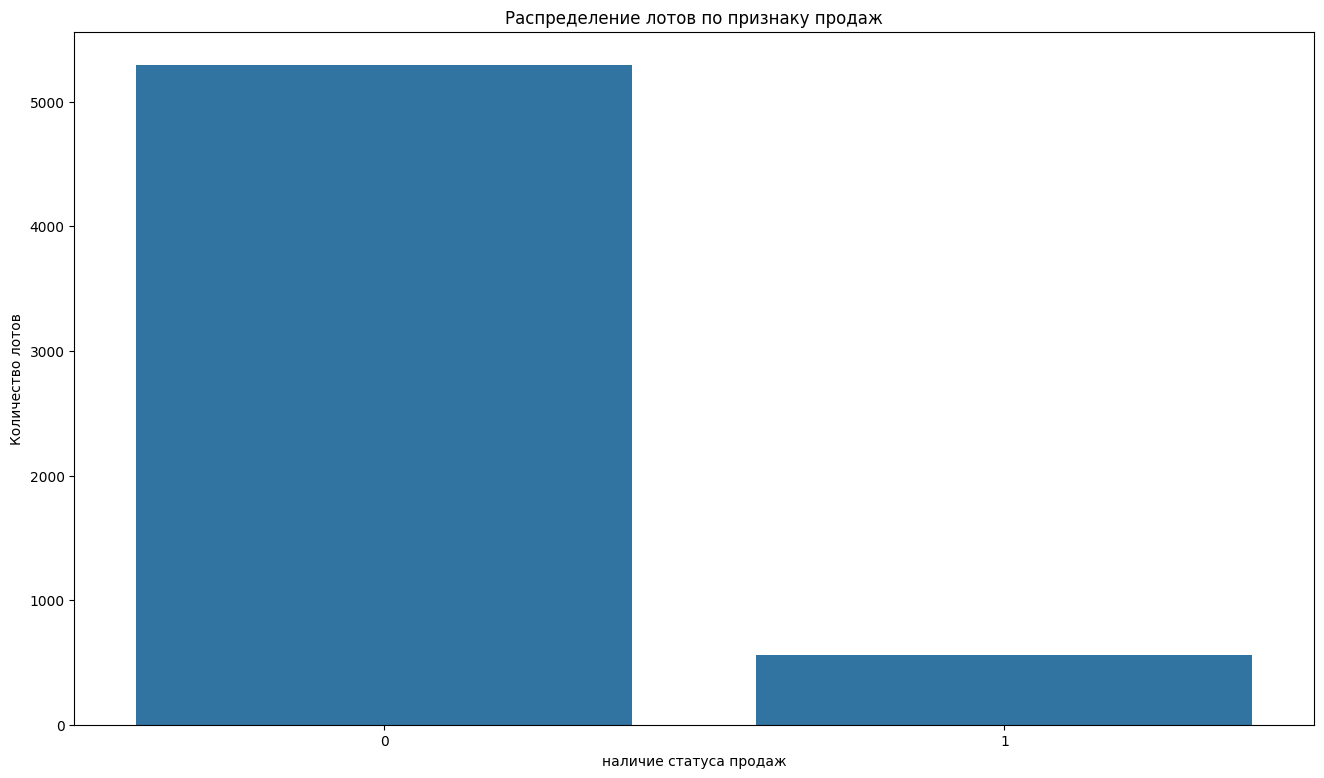

In [140]:
plt.figure(figsize=(16, 9))
sns.countplot(x='sold_flag', data=ebay_df_analysis)
plt.title('Распределение лотов по признаку продаж')
plt.xlabel('наличие статуса продаж')
plt.ylabel('Количество лотов')
plt.show()

На графике видно, что большинство лотов не имеют зафиксированного сигнала продаж, а успешные лоты составляют меньшую часть выборки. Это подтверждает, что признак sold_flag = 1 можно использовать как более строгий критерий успешности: продажа фиксируется не у всех товаров, а только у части действительно востребованных лотов

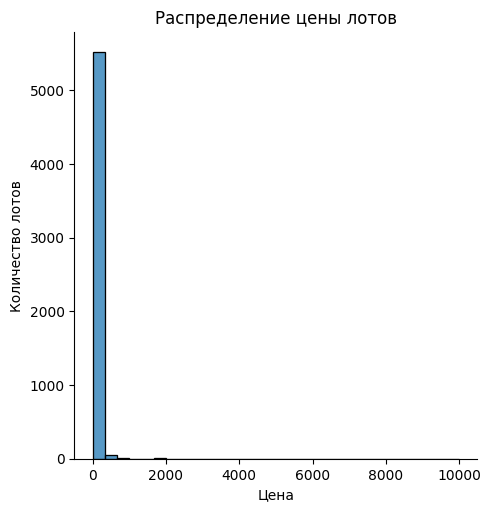

In [141]:
sns.displot(ebay_df_analysis['extracted_price'].dropna(), bins=30)
plt.title('Распределение цены лотов')
plt.xlabel('Цена')
plt.ylabel('Количество лотов')
plt.show()

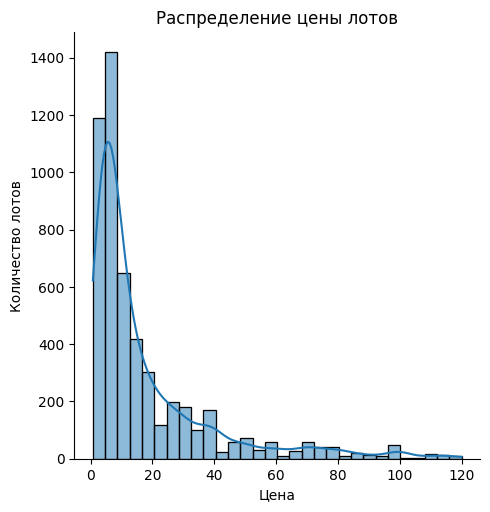

In [143]:
price_plot = ebay_df_analysis[ebay_df_analysis['extracted_price'] <= ebay_df_analysis['extracted_price'].quantile(0.95)]

sns.displot(price_plot['extracted_price'], bins=30, kde=True)

plt.title('Распределение цены лотов')
plt.xlabel('Цена')
plt.ylabel('Количество лотов')
plt.show()

В выборке много недорогих лотов и заметно меньше дорогих. Это значит, что рынок комиксов на eBay в основном состоит из сравнительно дешёвых предложений, а дорогие позиции встречаются реже

Теперь проверим связана ли более низкая цена с большей вероятностью продажи

In [144]:
ebay_df_analysis.groupby('sold_flag')['extracted_price'].describe()

,count,mean,std,min,25%,50%,75%,max
sold_flag,,,,,,,,
0,5022.0,38.800677,202.262954,0.7,4.99,9.99,25.0,10000.0
1,563.0,16.385844,26.928604,1.0,4.39,5.98,20.0,400.0


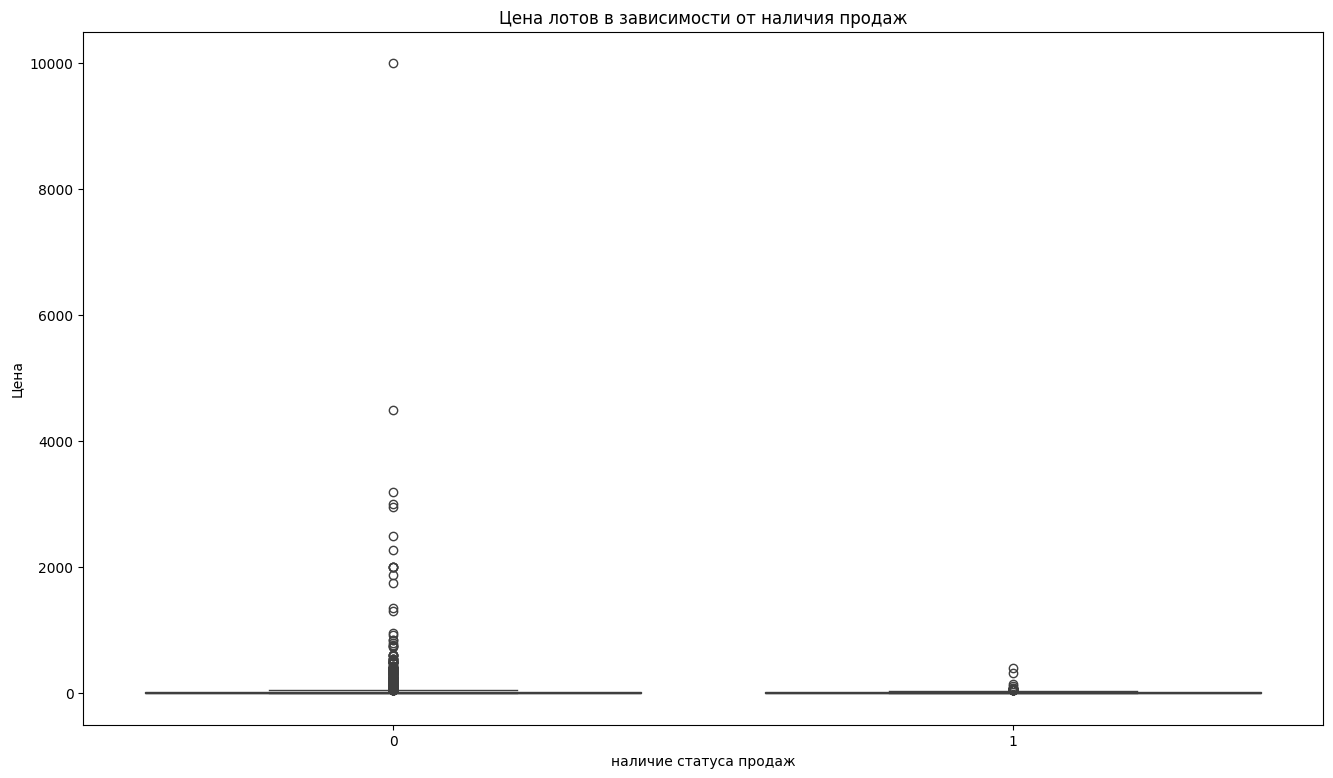

In [145]:
plt.figure(figsize=(16, 9))
sns.boxplot(x='sold_flag', y='extracted_price', data=ebay_df_analysis)
plt.title('Цена лотов в зависимости от наличия продаж')
plt.xlabel('наличие статуса продаж')
plt.ylabel('Цена')
plt.show()

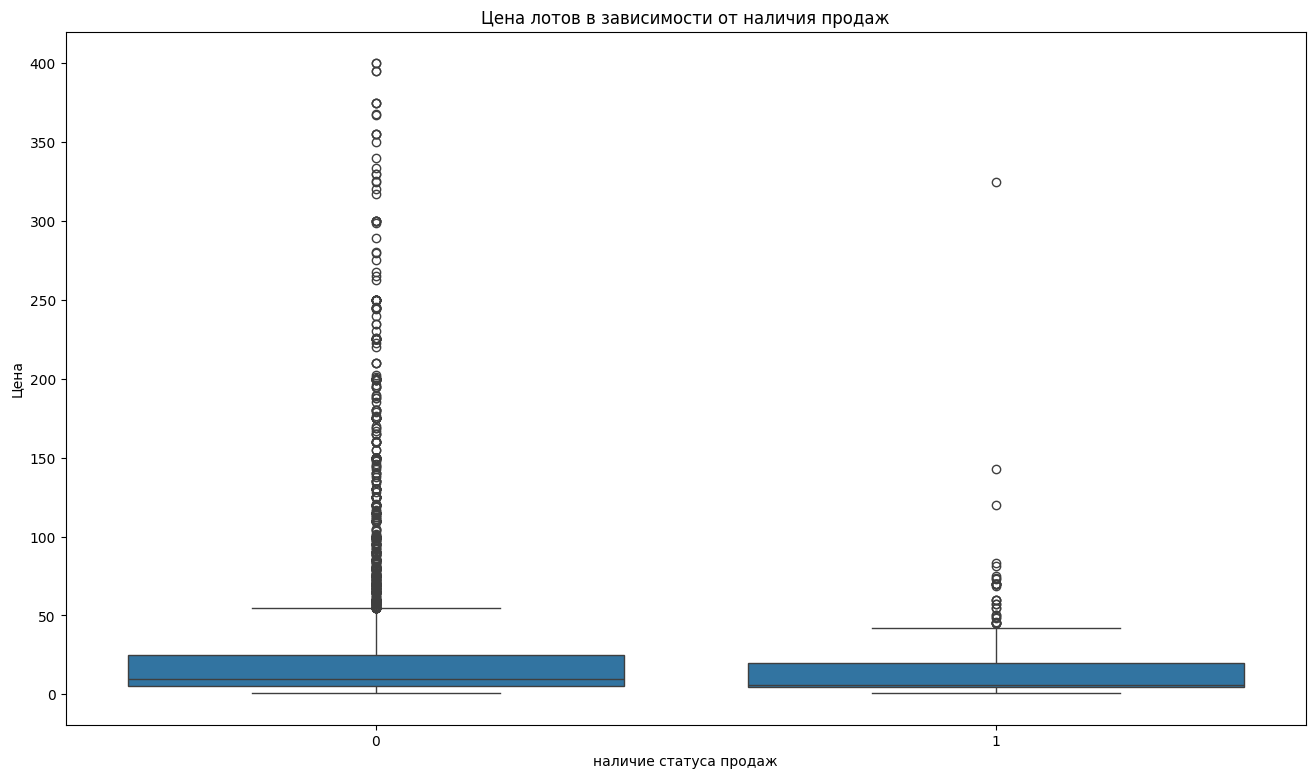

In [146]:
price_lim = ebay_df_analysis['extracted_price'].quantile(0.99)

plt.figure(figsize=(16, 9))
sns.boxplot(x='sold_flag', y='extracted_price', data=ebay_df_analysis[ebay_df_analysis['extracted_price'] <= price_lim])
plt.title('Цена лотов в зависимости от наличия продаж')
plt.xlabel('наличие статуса продаж')
plt.ylabel('Цена')
plt.show()

In [147]:
ebay_df_analysis.groupby('sold_flag')['extracted_price'].median()

,extracted_price
sold_flag,
0,9.99
1,5.98


Для сравнения цен успешных и неуспешных лотов был построен boxplot. Так как в выборке присутствуют очень дорогие выбросы, визуализация была ограничена 99-м перцентилем цены. Это позволило лучше увидеть основную часть распределения.
Дополнительно были рассчитаны медианные значения цены по группам. Для лотов без сигнала продаж медианная цена составила 9.99 долларов, а для лотов с сигналом продаж 5.98 долларов.

В выборке лоты с признаком продаж в среднем дешевле. Это позволяет выдвинуть гипотезу, что более низкая цена повышает вероятность продажи комиксного лота.

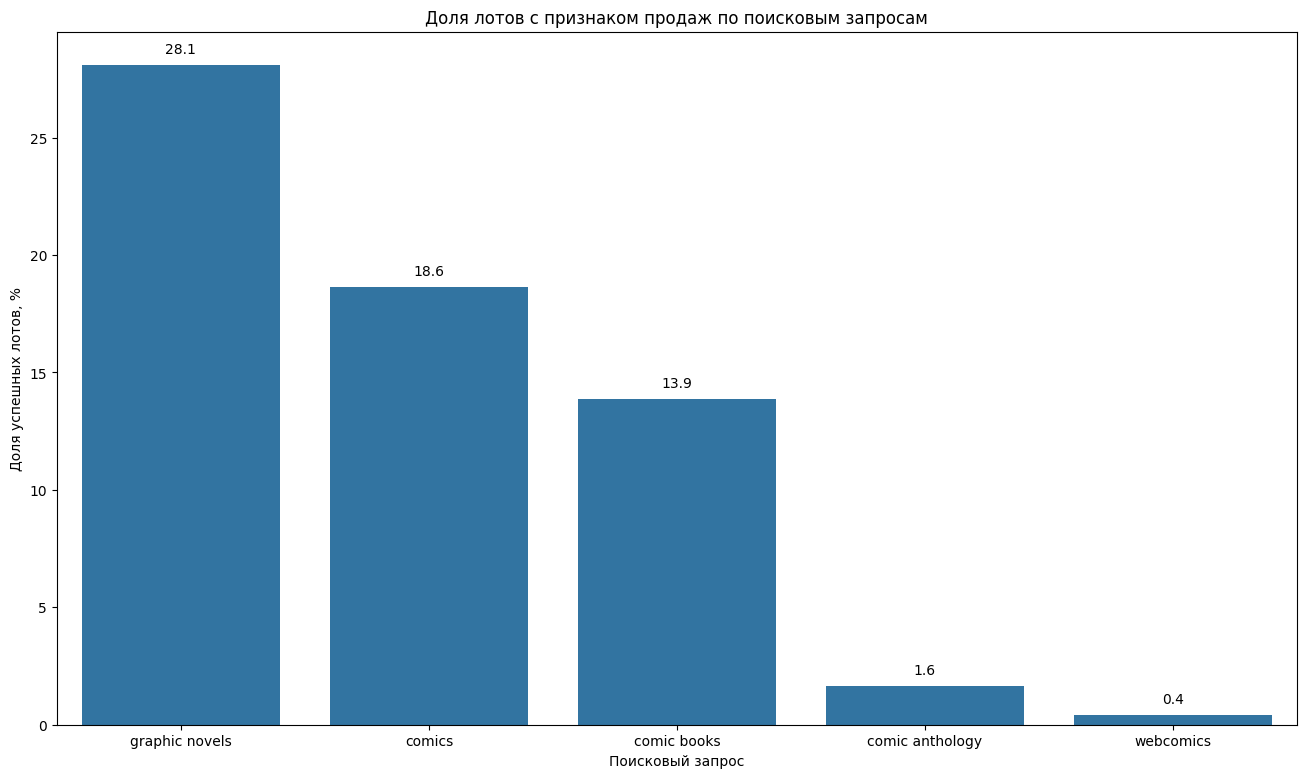

In [160]:
search_success = ebay_df_analysis.groupby('source_query', as_index=False)['sold_flag'].mean()
search_success = search_success.sort_values('sold_flag', ascending=False)
search_success['sold_flag_percent'] = search_success['sold_flag'] * 100

plt.figure(figsize=(16, 9))
ax = sns.barplot(x='source_query', y='sold_flag_percent', data=search_success)

for i in range(search_success.shape[0]):
    ax.text(i, search_success['sold_flag_percent'].iloc[i] + 0.5, round(search_success['sold_flag_percent'].iloc[i], 1), ha='center')

plt.title('Доля лотов с признаком продаж по поисковым запросам')
plt.xlabel('Поисковый запрос')
plt.ylabel('Доля успешных лотов, %')
plt.show()

На графике видно, что наибольшая доля лотов с признаком продаж наблюдается у graphic novels - около 28.1%. Далее идут comics и comic books, тогда как webcomics и comic anthology показывают значительно более слабые результаты

Можно предположить, что на eBay графические романы и классические комиксные издания имеют более высокий рыночный спрос, чем веб-комиксы и антологии.

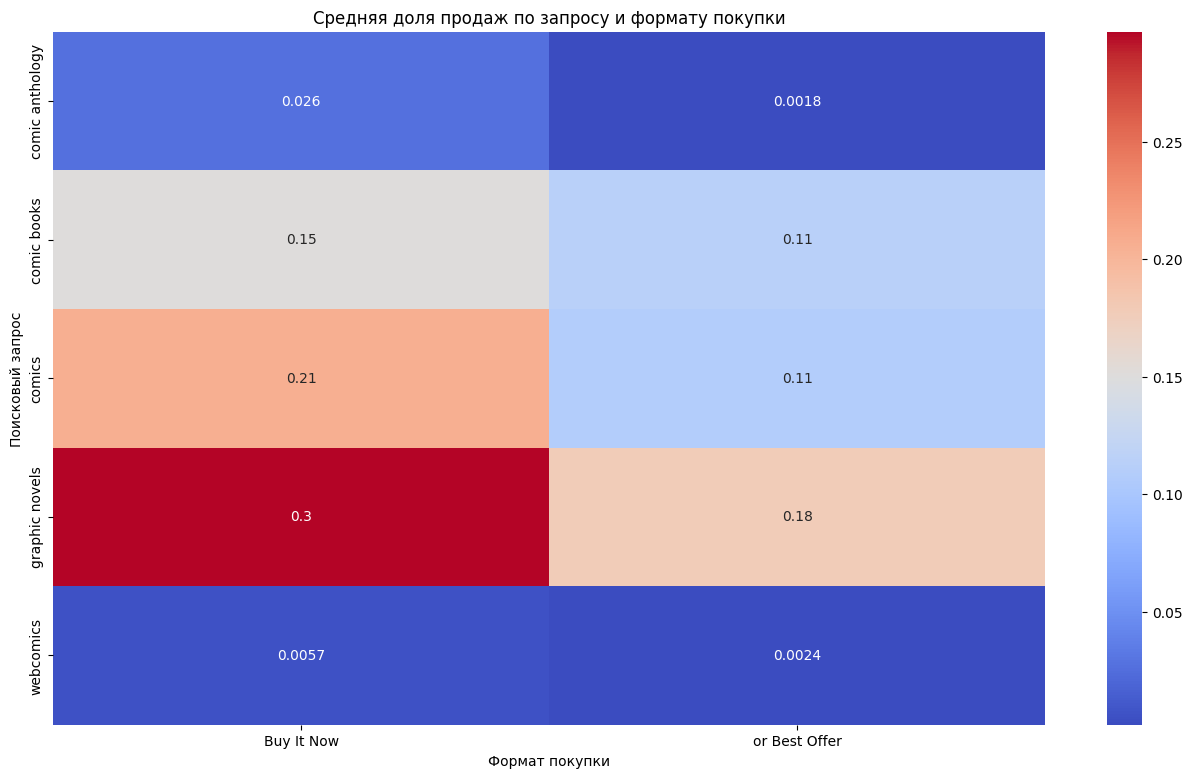

In [164]:
tmp = ebay_df_analysis
top_formats = tmp['buying_format'].value_counts().head(2).index
tmp = tmp[tmp['buying_format'].isin(top_formats)]

heatmap = tmp.pivot_table(index='source_query', columns='buying_format', values='sold_flag', aggfunc='mean')

plt.figure(figsize=(16, 9))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm')
plt.title('Средняя доля продаж по запросу и формату покупки')
plt.xlabel('Формат покупки')
plt.ylabel('Поисковый запрос')
plt.show()

Тепловая карта показывает, что наибольшая доля продаж наблюдается у graphic novels в формате Buy It Now. Для webcomics и comic anthology успешность остаётся низкой почти во всех форматах покупки

Теперь отдельно рассмотрим подвыборку с количеством продаж sold_cnt

In [151]:
ebay_df_sold = ebay_df_analysis[~ebay_df_analysis['sold_cnt'].isna()].copy()
ebay_df_sold.shape

(563, 11)

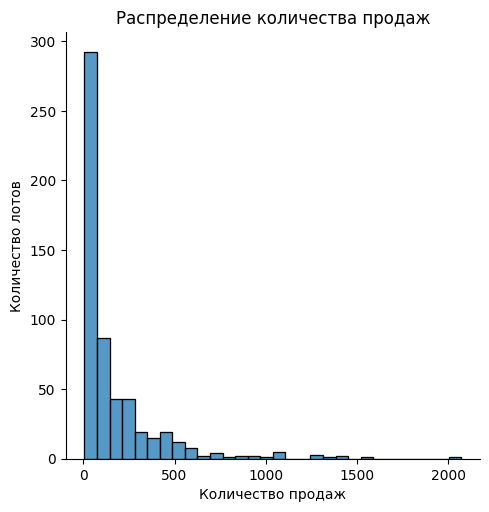

In [152]:
sns.displot(ebay_df_sold['sold_cnt'], bins=30)
plt.title('Распределение количества продаж')
plt.xlabel('Количество продаж')
plt.ylabel('Количество лотов')
plt.show()

In [153]:
search_sold_cnt = ebay_df_sold.groupby('source_query', as_index=False)['sold_cnt'].median()
search_sold_cnt = search_sold_cnt.sort_values('sold_cnt', ascending=False)
search_sold_cnt

,source_query,sold_cnt
3,graphic novels,94.5
0,comic anthology,71.0
2,comics,71.0
1,comic books,40.0
4,webcomics,20.0


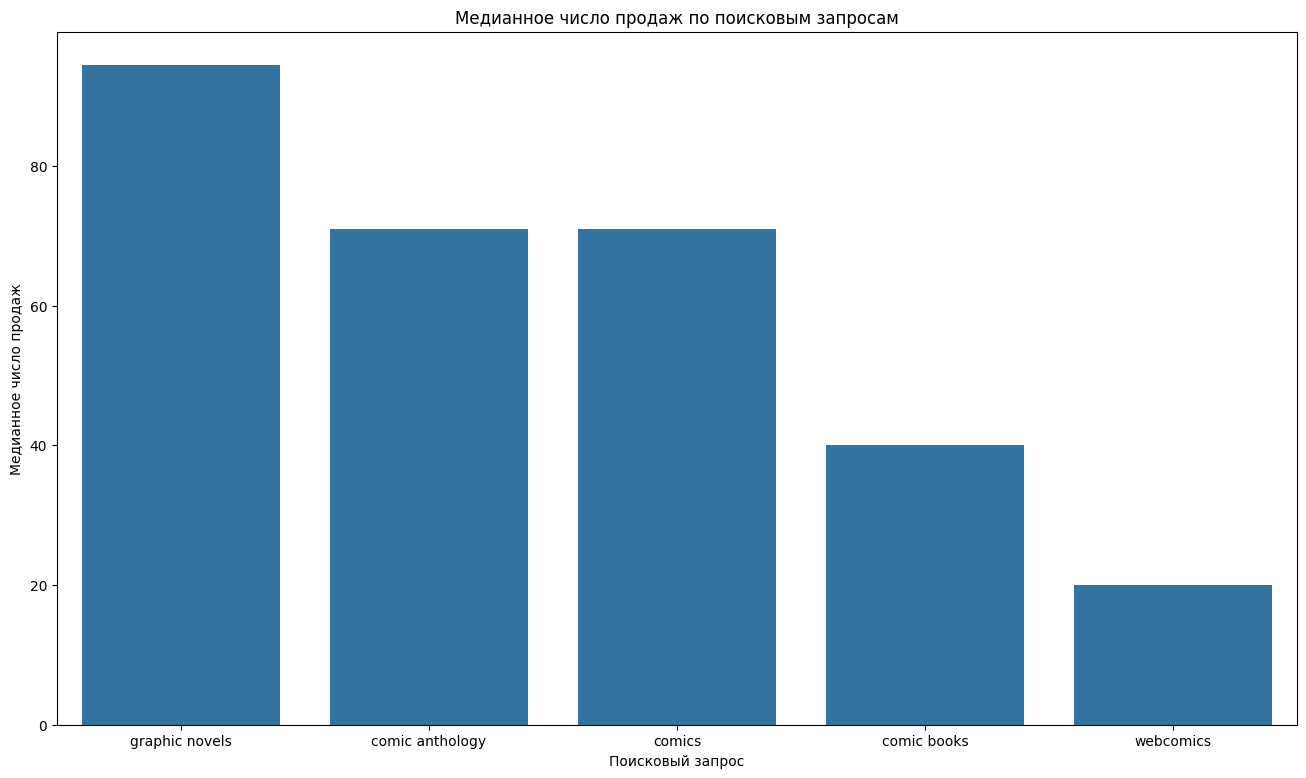

In [ ]:
plt.figure(figsize=(16, 9))
sns.barplot(x='source_query', y='sold_cnt', data=search_sold_cnt)
plt.title('Медианное число продаж по поисковым запросам')
plt.xlabel('Поисковый запрос')
plt.ylabel('Медианное число продаж')
plt.show()

Среди лотов, где продажи удалось извлечь количественно, лидером снова являются graphic novels. Затем идут comics вместе с comic anthology, а webcomics показывают самое низкое медианное число продаж. И это также, что графические романы и комиксы на eBay более востребованы

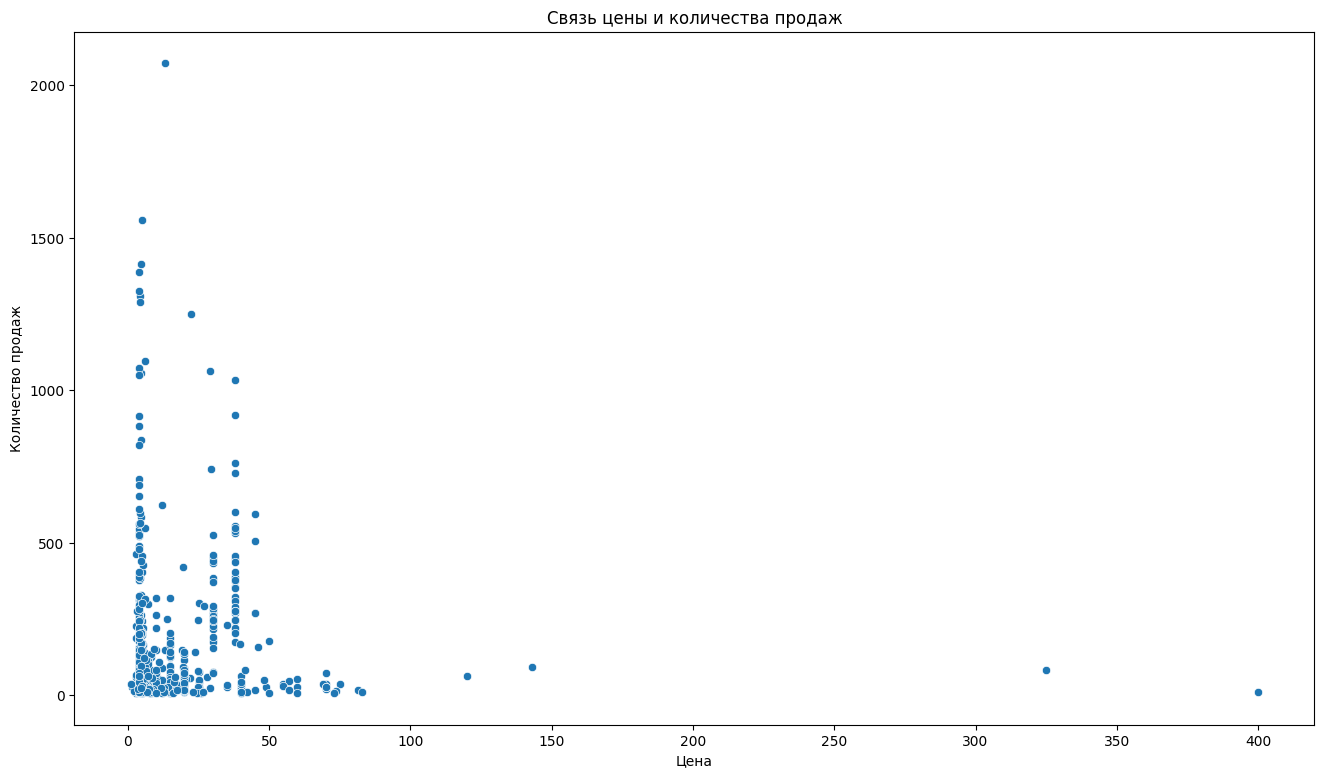

In [ ]:
plt.figure(figsize=(16, 9))
sns.scatterplot(x='extracted_price', y='sold_cnt', data=ebay_df_sold)
plt.title('Связь цены и количества продаж')
plt.xlabel('Цена')
plt.ylabel('Количество продаж')
plt.show()

Большинство лотов с высокими продажами сосредоточено в зоне сравнительно низких цен

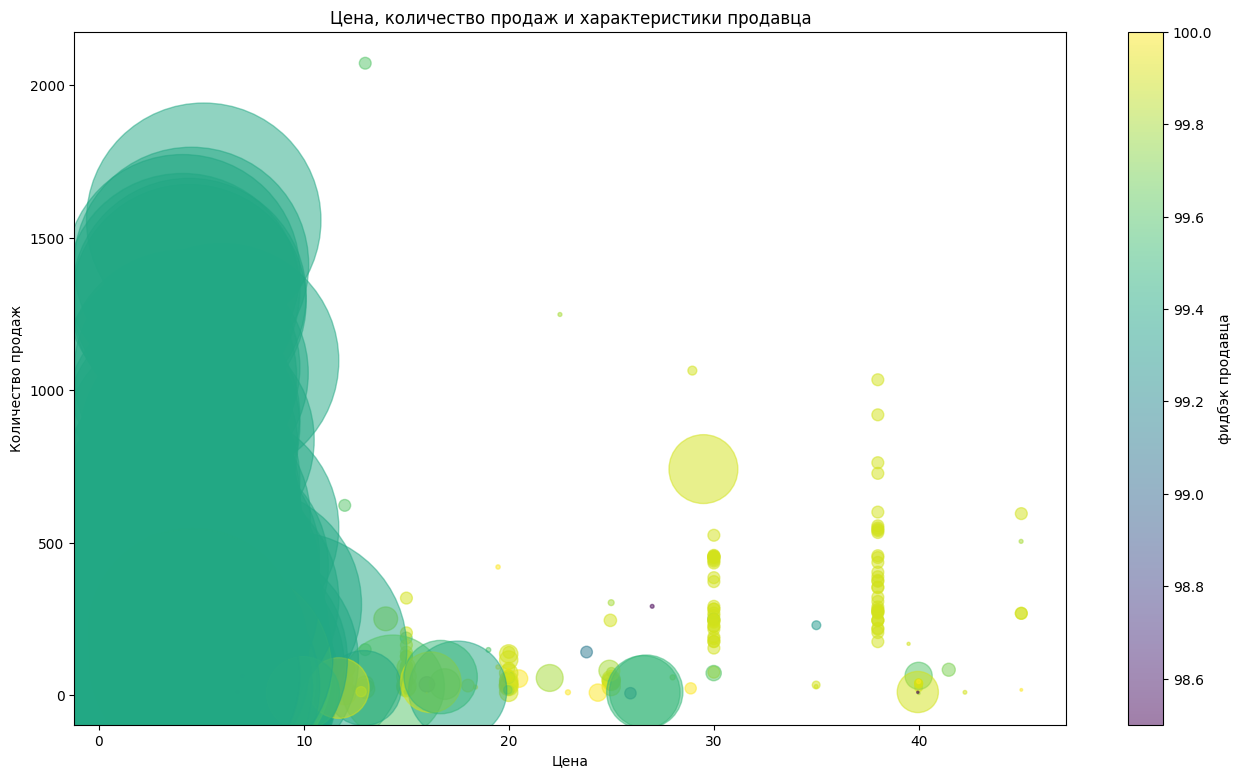

In [167]:
tmp = ebay_df_sold[ebay_df_sold['extracted_price'] <= ebay_df_sold['extracted_price'].quantile(0.95)]

fig, ax = plt.subplots(figsize=(16, 9))
color_graph = ax.scatter(tmp['extracted_price'], tmp['sold_cnt'], s=tmp['seller_reviews'] / 200, alpha=0.5, c=tmp['seller_feedback'], cmap='viridis')

plt.colorbar(color_graph, label='фидбэк продавца')
plt.title('Цена, количество продаж и характеристики продавца')
plt.xlabel('Цена')
plt.ylabel('Количество продаж')
plt.show()

Размер точек показывает, что в выборке присутствуют как крупные, так и менее крупные продавцы, однако визуально репутационные характеристики продавца не дают выраженного разделения между более и менее успешными лотами

ВИвод таков:

Проведённый анализ объявлений с eBay позволил использовать внешний рыночный спрос как дополнительный ориентир для оценки потенциальной успешности комиксных проектов на краудфандинговых платформах. Результаты показали, что наиболее сильные сигналы спроса наблюдаются у категории graphic novels, тогда как webcomics и comic anthology выглядят значительно менее востребованными. Кроме того, успешные объявления в среднем имеют более низкую медианную цену, что позволяет предположить, что для аудитории важен доступный ценовой порог. Таким образом, если переносить результаты на логику краудфандинга, то наибольший потенциал успеха могут иметь проекты в формате graphic novel и другие более востребованные традиционные комиксные форматы с умеренным уровнем запрашиваемой суммы